# Obligatorio - Taller de Deep Learning


**Fecha de entrega:** 3/12/2025  
**Puntaje máximo:** 50 puntos

**Alumno(s):** 
Rodrigo Benitez - 172018 | 
Chia I Lin Liu - 172155

## Obligatorio

El objetivo de este obligatorio es evaluar su conocimiento en Deep Learning mediante la implementación completa de un modelo de segmentación de imágenes basado en el paper [**"U-Net: Convolutional Networks for Biomedical Image Segmentation"**](https://arxiv.org/pdf/1505.04597). Toda la implementación debe realizarse desde cero utilizando PyTorch, y los estudiantes tendrán la libertad de ajustar ciertos hiperparámetros y configuraciones mientras mantengan la esencia del paper original.

### **Competencia en Kaggle**

Además, como parte de este obligatorio, participarán en una competencia privada en Kaggle donde se les proporcionará un dataset de test oculto (sin target). Deberán subir sus predicciones a Kaggle y se evaluarán en función de la métrica **Dice Coefficient (Coeficiente de Dice)**. Esta competencia les permitirá comparar sus resultados con los de sus compañeros en un entorno real de evaluación.

### **¿Qué es el Dice Coefficient?**
El **Dice Coefficient**, también conocido como F1-score para segmentación, es una métrica utilizada para evaluar la similitud entre la predicción y la verdad del terreno en tareas de segmentación. Se define de la siguiente manera:

$$
\text{Dice} = \frac{2 \cdot |A \cap B|}{|A| + |B|}
$$

Donde:
- $A$ es el conjunto de píxeles predichos como pertenecientes a la clase positiva.
- $B$ es el conjunto de píxeles verdaderos pertenecientes a la clase positiva.
- $|A \cap B|$ es la intersección de $A$ y $B$, es decir, los píxeles correctamente predichos como positivos.

Un valor de Dice de **1** indica una predicción perfecta, mientras que un valor de **0** indica que no hay coincidencia entre la predicción y el valor verdadero. Durante la competencia de Kaggle, deberán obtener un puntaje de al menos **0.75** en la métrica Dice para considerarse aprobados.

### **Criterios a Evaluar**

1. **Análisis del Dataset (5 puntos):**
   - Exploración y visualización del dataset para comprender su estructura y características.
   - Justificación de las decisiones tomadas en la preprocesamiento de datos, como normalización, aumento de datos (data augmentation), y partición del dataset en conjuntos de entrenamiento, validación y prueba.

2. **Implementación Correcta del Modelo U-Net (20 puntos):**
   - Construcción de la arquitectura U-Net siguiendo la estructura descrita en el paper, permitiendo ajustes como el número de filtros, funciones de activación y métodos de inicialización de pesos.
   - Se aceptan mejoras como el uso de técnicas adicionales como batch normalization, otras funciones de activación, etc.

3. **Entrenamiento del Modelo (10 puntos):**
   - Configuración adecuada del ciclo de entrenamiento, incluyendo la elección de la función de pérdida y del optimizador (Adam, SGD, etc.).
   - Uso de técnicas de regularización para mejorar la generalización del modelo, como el dropout, normalización de batch y data augmentation.
   - Gráficas y análisis de la evolución del entrenamiento, mostrando las curvas de pérdida y métricas relevantes tanto en el conjunto de entrenamiento como en el de validación.
   - Puede utilizarse experimentación con hiperparámetros con Weights & Biases (W&B) para optimizar el rendimiento del modelo. Este punto no es obligatorio, pero se valorará positivamente si se justifica su uso y se presentan resultados claros.

4. **Evaluación de Resultados (10 puntos):**
   - Evaluación exhaustiva del modelo utilizando métricas de segmentación como **Dice Coefficient**.
   - Análisis detallado de los resultados, incluyendo un análisis de errores para identificar y discutir casos difíciles.
   - Visualización de ejemplos representativos de segmentaciones correctas e incorrectas, comparando con las etiquetas manuales proporcionadas en el dataset.

5. **Participación y Resultados en la Competencia Kaggle (5 puntos):**
   - Participación activa en la competencia de Kaggle, con al menos una (1) subida de predicción.
   - Puntaje obtenido en la tabla de posiciones de Kaggle, evaluado en base al **Dice Coefficient** en el conjunto de test oculto. Es necesario obtener al menos un valor de **0.75** para esta métrica.

   Notas: 
   - **Cualquier decisión debe ser justificada en el notebook.**
   - El **Dice Coefficient** es la métrica utilizada para evaluar la precisión de los modelos de segmentación de imágenes en esta competencia.

### **Run-Length Encoding (RLE)**

Dado que no se suben las imágenes segmentadas directamente a Kaggle, se requiere usar **Run-Length Encoding (RLE)** para comprimir las máscaras de predicción en una cadena de texto que será evaluada. El **RLE** es una técnica de compresión donde se representan secuencias consecutivas de píxeles en formato `start length`, indicando la posición de inicio y la longitud de cada secuencia de píxeles positivos.

Para calcular el **RLE**, se sigue el siguiente proceso:

1. Se aplanan las máscaras predichas en un solo vector
2. Se identifican los píxeles con valor positivo (1) y se calculan las secuencias consecutivas.
3. Se registra la posición de inicio de cada secuencia y su longitud en formato `start length`.

Este formato comprimido se sube a Kaggle en lugar de las imágenes segmentadas.

#### **Ejemplo de RLE**

```python
import numpy as np

def rle_encode(mask):
    pixels = np.array(mask).flatten(order='F')  # Aplanar la máscara en orden Fortran
    pixels = np.concatenate([[0], pixels, [0]])  # Añadir ceros al principio y final
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1  # Encontrar transiciones
    runs[1::2] = runs[1::2] - runs[::2]  # Calcular longitudes
    return ' '.join(str(x) for x in runs)

mask = np.array([[0, 0, 1, 0, 0],
                 [0, 1, 1, 1, 0],
                 [1, 1, 1, 0, 0],
                 [0, 0, 0, 1, 1]])

print(rle_encode(mask))
```

> **Salida:** 3 1 6 2 9 3 14 1 16 1 20 1


### **Sobre el Dataset**

El dataset proporcionado para esta tarea incluirá imágenes y máscaras para la segmentación de un conjunto específico de clases. El conjunto de entrenamiento estará disponible para su uso durante todo el proceso de desarrollo y pruebas, mientras que el conjunto de validación se mantendrá oculto para la evaluación final en Kaggle.

### **Instrucciones de Entrega**

- Deberán entregar un Jupyter Notebook (.ipynb) que contenga todo el código y las explicaciones necesarias para ejecutar la implementación, el entrenamiento y la evaluación del modelo.
- El notebook debe incluir secciones bien documentadas explicando las decisiones de diseño del modelo, los experimentos realizados, y los resultados obtenidos.
- El código debe estar escrito de manera clara.
- La entrega debe realizarse a través de la plataforma de gestión de ORT (gestion.ort.edu.uy) antes de la fecha límite.

### **Materiales Adicionales**

Para facilitar su trabajo, pueden consultar los siguientes recursos:

- [U-Net: Convolutional Networks for Biomedical Image Segmentation (paper original)](https://arxiv.org/abs/1505.04597)
- [Documentación de PyTorch](https://pytorch.org/docs/stable/index.html)
- [Tutoriales y recursos adicionales en Kaggle](https://www.kaggle.com/)
- [Convolución Transpuesta](https://d2l.ai/chapter_computer-vision/transposed-conv.html)

### **Competencia Kaggle**

[Link a la competencia Kaggle](https://www.kaggle.com/competitions/tdl-obligatorio-2025)

---

# Librerías

In [128]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import v2 as T
from torchvision.io import read_image, ImageReadMode
from torchvision.datasets import Imagenette
from torchvision.datasets import ImageNet
from torchinfo import summary

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import sys
import tarfile
import urllib.request
import re
from pathlib import Path
from collections import Counter
from itertools import chain

from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

from utils import (
    find_mask_for_image,
    ensure_same_size,
    overlay_mask_on_image
)


In [129]:
os.getcwd()

'c:\\Users\\rodri\\OneDrive\\Documentos\\GitHub\\ORT-AI\\Deep Learning\\Taller de DL\\Tareas\\Obligatorio'

In [130]:
# Fijamos la semilla para que los resultados sean reproducibles
SEED = 34

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [131]:
import sys

# definimos el dispositivo que vamos a usar
DEVICE = "cpu"  # por defecto, usamos la CPU
if torch.cuda.is_available():
    DEVICE = "cuda"  # si hay GPU, usamos la GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"  # si no hay GPU, pero hay MPS, usamos MPS
elif torch.xpu.is_available():
    DEVICE = "xpu"  # si no hay GPU, pero hay XPU, usamos XPU

print(f"Usando {DEVICE}")

NUM_WORKERS = 0 # Win y MacOS pueden tener problemas con múltiples workers
if sys.platform == 'linux':
    NUM_WORKERS = 4  # numero de workers para cargar los datos (depende de cada caso)

print(f"Usando {NUM_WORKERS}")


Usando cuda
Usando 0


In [132]:
BATCH_SIZE = 4  # tamaño del batch

# Config Weight & Bias

In [133]:
import wandb

In [134]:
wandb.login(key="371d1ec6f09f8bd9b3f43d38d319dae857ea940f")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\rodri\_netrc


True

# Imagenes y mascaras

In [135]:
from typing import List, Optional, Tuple
import random
from PIL import Image

In [136]:
# Directorio de entrenamiento
TRAIN_DIR = Path("./data/train")
IMAGES_DIR = TRAIN_DIR / "images"
MASKS_DIR = TRAIN_DIR / "masks"

In [137]:
# Extensiones válidas para imágenes
VALID_EXTS = {".png"}

# Recolectamos imágenes disponibles
image_files: List[Path] = [p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in VALID_EXTS]
image_files.sort()
print(f"Imágenes encontradas: {len(image_files)} en {IMAGES_DIR}")

Imágenes encontradas: 2133 en data\train\images


In [138]:
# Visualización de una muestra aleatoria de pares imagen-máscara
NUM_SAMPLES = 6 
if len(image_files) == 0:
    raise RuntimeError("No se encontraron imágenes para visualizar")

sample_paths = random.sample(image_files, k=min(NUM_SAMPLES, len(image_files)))

In [139]:
# Toggle para mostrar overlay
SHOW_OVERLAY = True
OVERLAY_COLOR = (0, 255, 0)  # color verde para las máscaras
ALPHA = 0.35

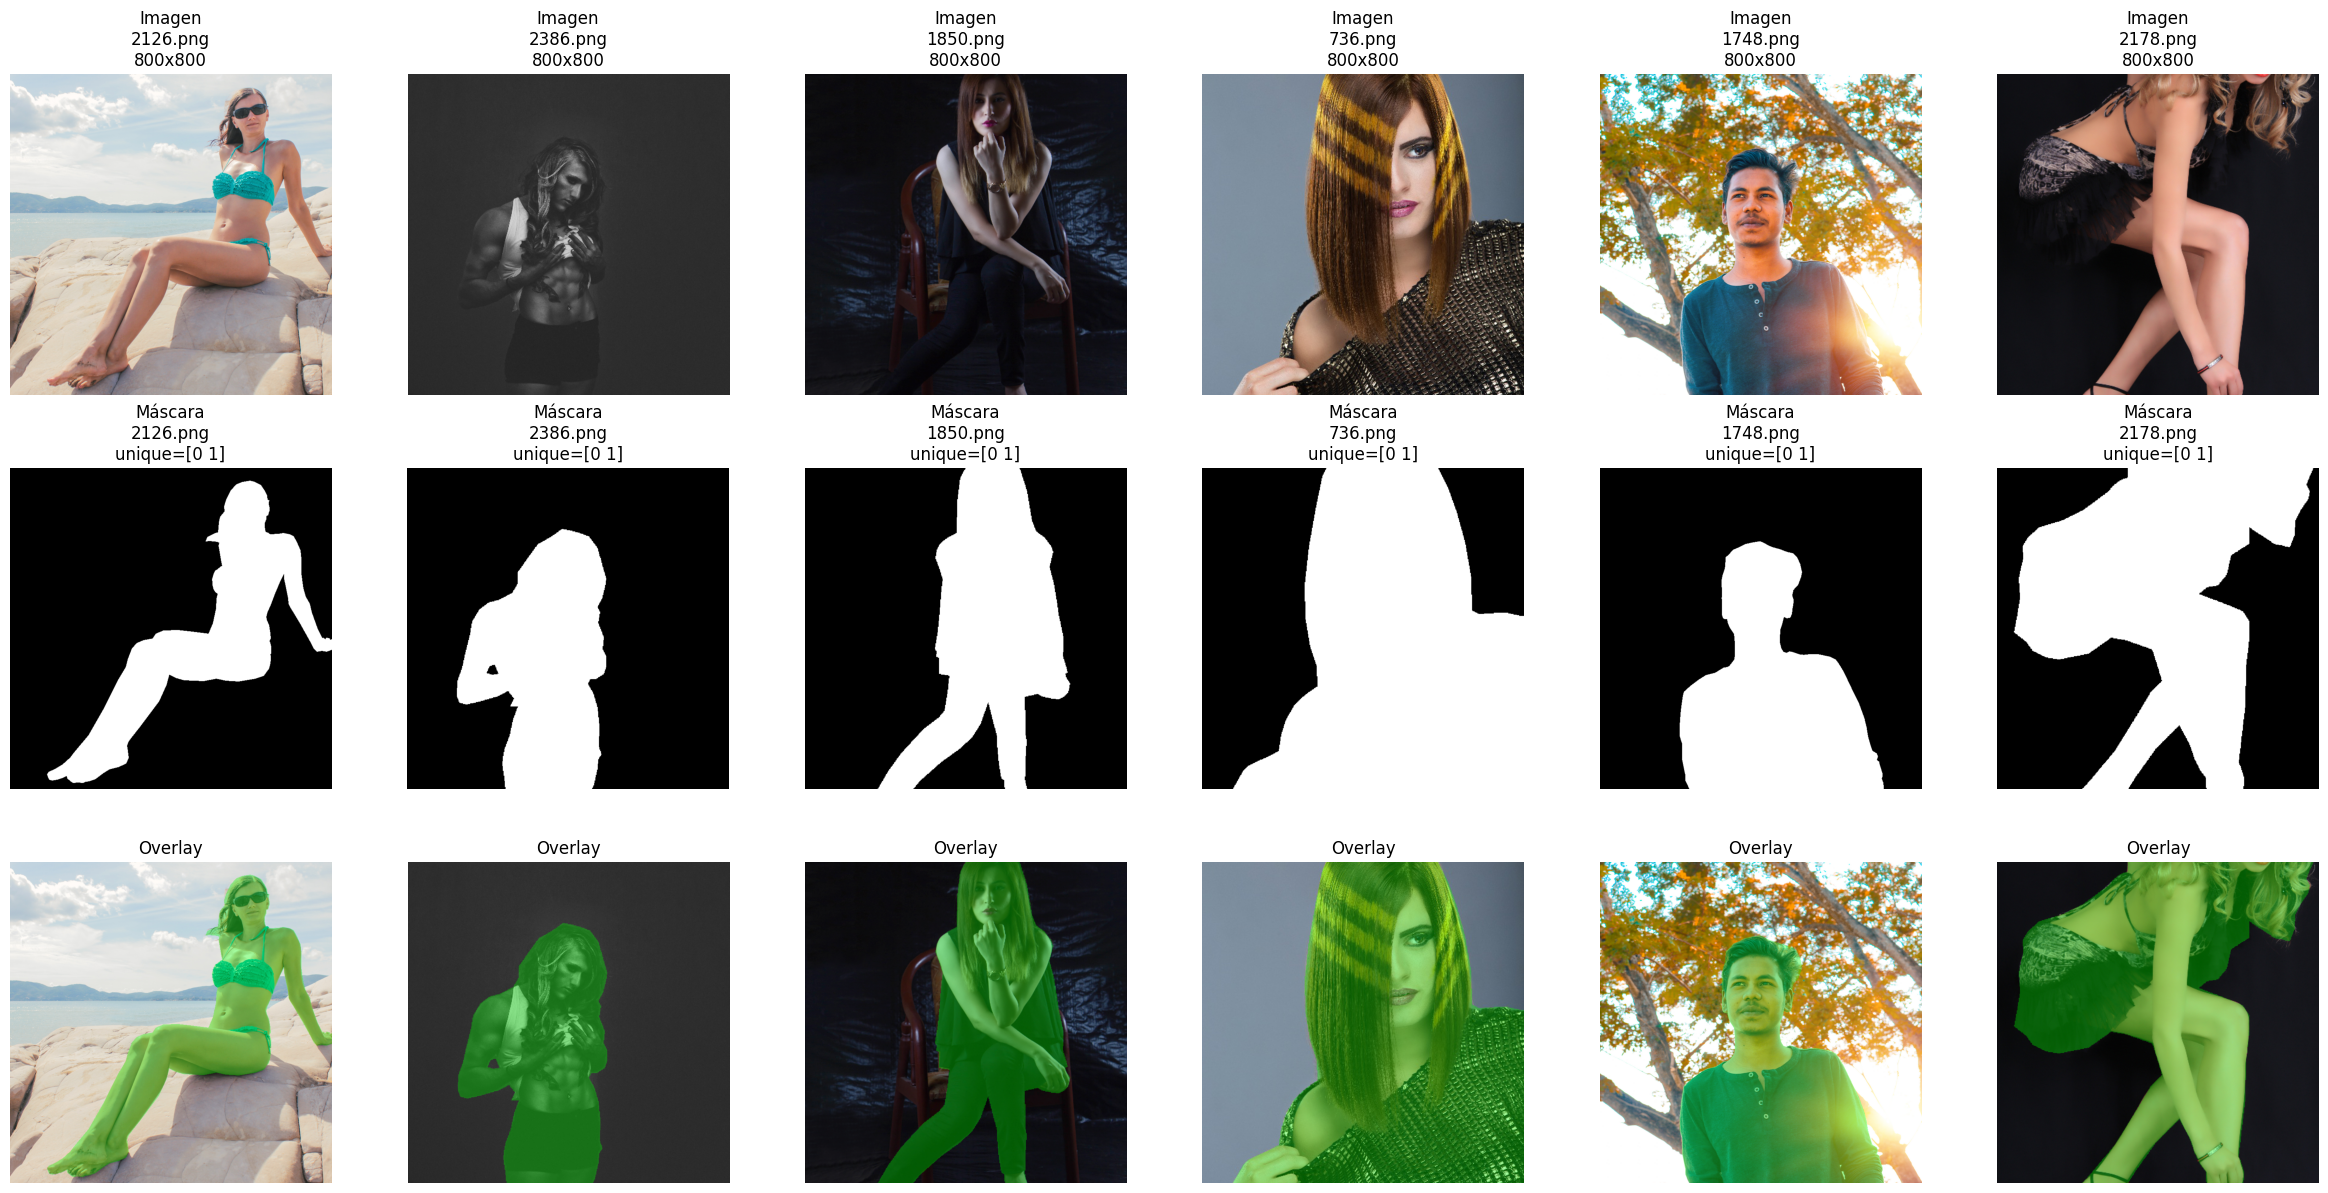

In [140]:
# Construimos las figuras
cols = len(sample_paths)
rows = 3 if SHOW_OVERLAY else 2
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
if cols == 1:
    axes = np.array(axes).reshape(rows, 1)

for j, img_path in enumerate(sample_paths):
    mask_path = find_mask_for_image(img_path)

    img = Image.open(img_path).convert("RGB")
    if mask_path is not None:
        mask = Image.open(mask_path).convert("L")
        img, mask = ensure_same_size(img, mask)
        mask_np = np.array(mask)
        uniq = np.unique(mask_np)
    else:
        mask = None
        uniq = None

    # Fila 0: imagen
    axes[0, j].imshow(img)
    axes[0, j].set_title(f"Imagen\n{img_path.name}\n{img.size[0]}x{img.size[1]}")
    axes[0, j].axis("off")

    # Fila 1: máscara si existe
    if mask is not None:
        axes[1, j].imshow(mask, cmap="gray")
        axes[1, j].set_title(
            f"Máscara\n{mask_path.name}\nunique={uniq[:8]}{'...' if uniq is not None and len(uniq) > 8 else ''}"
        )
        axes[1, j].axis("off")

    # Fila 2: Overlay
        if SHOW_OVERLAY:
            overlay = overlay_mask_on_image(img, mask, color=OVERLAY_COLOR, alpha=ALPHA)
            axes[2, j].imshow(overlay)
            axes[2, j].set_title("Overlay")
            axes[2, j].axis("off")
    else:
        axes[1, j].text(0.5, 0.5, "Sin máscara", ha="center", va="center")
        axes[1, j].axis("off")
        if SHOW_OVERLAY:
            axes[2, j].axis("off")

plt.tight_layout()
plt.show()

# Resumen breve
num_with_mask = sum(1 for p in image_files if find_mask_for_image(p) is not None)


# EDA 

## Dimensiones de imágenes

In [141]:
sizes = []  # (W, H)
for p in image_files:
    try:
        with Image.open(p) as im:
            sizes.append(im.size)
    except Exception as e:
        print(f"Advertencia: no se pudo abrir {p.name}: {e}")

sizes = np.array(sizes)
widths = sizes[:, 0]
heights = sizes[:, 1]
aspect = widths / heights

print(f"Total de imágenes analizadas: {len(sizes)}")
print(f"Width px -> min:{widths.min()}  max:{widths.max()}")
print(f"Height px -> min:{heights.min()}  max:{heights.max()}")
print(f"Aspect ratio -> min:{aspect.min():.3f}  max:{aspect.max():.3f}")


Total de imágenes analizadas: 2133
Width px -> min:800  max:800
Height px -> min:800  max:800
Aspect ratio -> min:1.000  max:1.000


Debemos resizear a múltiplos de 32 (p.ej. 256/384/512), normalización con mu/std arriba, para modelo U-Net es mejor manejar ese tipo de sizes.

## Intensidad de canales RGB

In [142]:
pairs = [(p, find_mask_for_image(p, MASKS_DIR, VALID_EXTS)) for p in image_files]

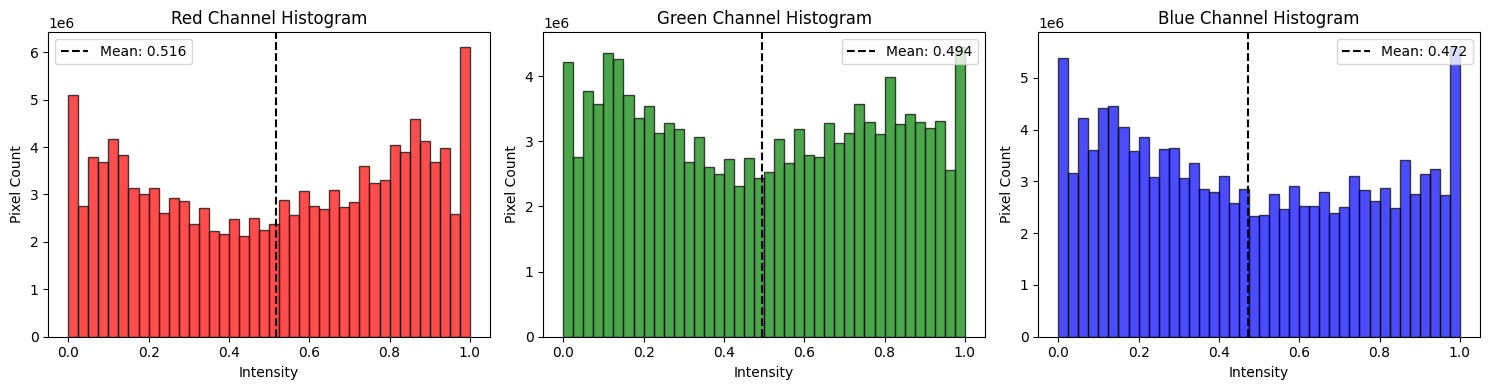

C:\Users\rodri\AppData\Local\Temp\ipykernel_16332\1706264464.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[:,0], X[:,1], X[:,2]], labels=['Red','Green','Blue'], patch_artist=True,


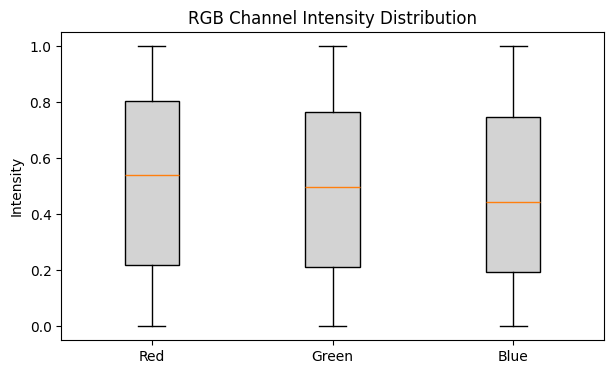

mu: [0.51611766 0.49368221 0.47191136] std: [0.31297951 0.30229255 0.30732669] min/max: (array([0., 0., 0.]), array([1., 1., 1.]))


In [143]:
def rgb_stats(paths, sample=200, show_plots=True):
    paths = paths[:min(sample, len(paths))]
    chans = []
    for p in paths:
        arr = np.array(Image.open(p).convert("RGB")).reshape(-1,3)
        chans.append(arr)
    X = np.vstack(chans)/255.0
    mu = X.mean(0)
    std = X.std(0)
    rng = (X.min(0), X.max(0))
    
    if show_plots:
        # Histograms for each channel
        fig, axs = plt.subplots(1, 3, figsize=(15, 4))
        colors = ['red','green','blue']
        channel_names = ['Red', 'Green', 'Blue']
        for i, ax in enumerate(axs):
            ax.hist(X[:,i], bins=40, color=colors[i], alpha=0.7, edgecolor='black')
            ax.set_title(f'{channel_names[i]} Channel Histogram')
            ax.set_xlabel('Intensity')
            ax.set_ylabel('Pixel Count')
            ax.axvline(mu[i], color='k', linestyle='--', label=f'Mean: {mu[i]:.3f}')
            ax.legend()
        plt.tight_layout()
        plt.show()
        
        # Boxplot for channel intensity distributions
        plt.figure(figsize=(7,4))
        plt.boxplot([X[:,0], X[:,1], X[:,2]], labels=['Red','Green','Blue'], patch_artist=True,
                    boxprops=dict(facecolor='lightgray'))
        plt.title('RGB Channel Intensity Distribution')
        plt.ylabel('Intensity')
        plt.show()
    
    return mu, std, rng

mu, sd, rng = rgb_stats([p for p,_ in pairs])
print("mu:", mu, "std:", sd, "min/max:", rng)

Leve “color cast” cálido: medias R≈0.516 > G≈0.494 > B≈0.472. 
Indica sesgo a rojos (iluminación/white balance). => Conviene normalizar con estadísticas del dataset y usar color jitter moderado para robustez.

Rango amplio 0–1 sin clipping severo: hay presencia en todo el rango, para confirmar medir % de píxeles en [0,0.01] y [0.99,1]. (Si es alto, evaluá corrección de exposición o limitar aumentos.)

Queremos evitar clipping, que sería entrenar con imágenes “saturadas” (sobreexpuestas o subexpuestas) donde muchas zonas están pegadas a 0 o a 1. Eso implica pérdida de detalle en sombras y altas luces, menor contraste útil, medias/desvíos sesgados para la normalización y augmentations menos realistas. El modelo aprende con menos información y generaliza peor.

In [144]:
# Medir % de pixeles en los extremos del rango para cada canal

def get_clipping_stats(paths, sample=200):
    paths = paths[:min(sample, len(paths))]
    chans = []
    for p in paths:
        arr = np.array(Image.open(p).convert("RGB")).reshape(-1,3)
        chans.append(arr)
    X = np.vstack(chans)/255.0  # Normalizado a [0,1]

    thresholds = [(0,0.01), (0.99,1.0)]
    stats = {}
    channel_names = ['Red', 'Green', 'Blue']
    for i, name in enumerate(channel_names):
        low_pct = np.mean((X[:,i] >= thresholds[0][0]) & (X[:,i] <= thresholds[0][1])) * 100
        high_pct = np.mean((X[:,i] >= thresholds[1][0]) & (X[:,i] <= thresholds[1][1])) * 100
        stats[name] = {'pct_in_[0,0.01]': low_pct, 'pct_in_[0.99,1]': high_pct}
    return stats

clip_stats = get_clipping_stats([p for p,_ in pairs])
for c in clip_stats:
    print(f"Canal {c}:")
    print(f"  % pixeles en [0, 0.01]: {clip_stats[c]['pct_in_[0,0.01]']:.2f}%")
    print(f"  % pixeles en [0.99, 1]: {clip_stats[c]['pct_in_[0.99,1]']:.2f}%")


Canal Red:
  % pixeles en [0, 0.01]: 2.49%
  % pixeles en [0.99, 1]: 3.33%
Canal Green:
  % pixeles en [0, 0.01]: 2.08%
  % pixeles en [0.99, 1]: 2.49%
Canal Blue:
  % pixeles en [0, 0.01]: 2.61%
  % pixeles en [0.99, 1]: 2.98%


Medias de canales mantienen una relación R>G>B. Cosas que podemos hacer más adelante, mantener normalización con medias/STD y añadir ColorJitter moderado para robustez al balance de blancos.

## Cobertura de Personas en imagenes

In [145]:
paths = sorted(list[Path](IMAGES_DIR.glob("*")))
paths = [p for p in paths if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}]

In [146]:
coverages = []  # fracción [0,1]
pairs_idx = []   # índices válidos con máscara
empty_masks = 0
missing_masks = 0
for i, ip in enumerate(paths):
    mp = find_mask_for_image(ip)  # deduce ../masks
    if mp is None:
        missing_masks += 1
        continue
    mask = Image.open(mp).convert("L")
    # Binarizamos por >0 para abarcar 0/1 o 0/255
    m = (np.array(mask) > 0).astype(np.uint8)
    cov = float(m.mean())
    coverages.append(cov)
    pairs_idx.append(i)
    if cov == 0.0:
        empty_masks += 1

coverages = np.array(coverages)

In [147]:
if coverages.size == 0:
    raise RuntimeError("No se encontraron máscaras válidas para calcular cobertura.")

print(f"Total imágenes: {len(paths)}")
print(f"Con máscara: {len(coverages)} | Sin máscara: {missing_masks}")
print(f"Máscaras vacías: {empty_masks}")
print(
    f"Cobertura (pct): min={coverages.min()*100:.3f}  p25={np.percentile(coverages,25)*100:.3f}  "
    f"p50={np.percentile(coverages,50)*100:.3f}  p75={np.percentile(coverages,75)*100:.3f}  "
    f"max={coverages.max()*100:.3f}  mean={coverages.mean()*100:.3f}"
)

Total imágenes: 2133
Con máscara: 2133 | Sin máscara: 0
Máscaras vacías: 0
Cobertura (pct): min=1.037  p25=22.954  p50=38.466  p75=54.565  max=100.000  mean=39.899


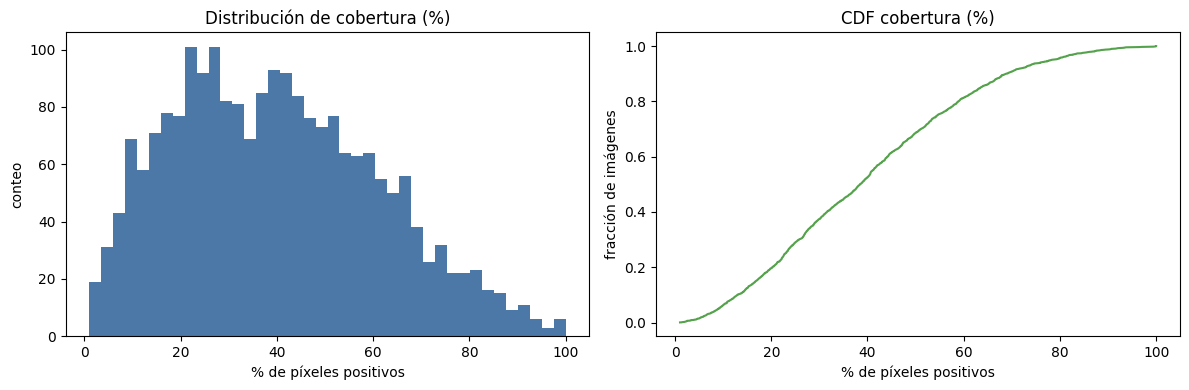

In [148]:
# Histograma y CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(coverages*100, bins=40, color="#4C78A8")
axes[0].set_title("Distribución de cobertura (%)")
axes[0].set_xlabel("% de píxeles positivos"); axes[0].set_ylabel("conteo")

sorted_cov = np.sort(coverages)
cdf = np.arange(1, len(sorted_cov)+1) / len(sorted_cov)
axes[1].plot(sorted_cov*100, cdf, color="#54A24B")
axes[1].set_title("CDF cobertura (%)")
axes[1].set_xlabel("% de píxeles positivos"); axes[1].set_ylabel("fracción de imágenes")
plt.tight_layout(); plt.show()


- Cobertura: distribución ancha con pico en coberturas medias (≈20–60%). Hay pocas imágenes con cobertura muy baja (<10%) y pocas saturadas (>90%). La CDF sube de forma casi lineal entre 10–80%, lo que sugiere mediana alrededor de 40–50%.

- Implicancia: el desbalance “fondo vs persona” no es extremo. Para la pérdida, BCE+Dice es una elección segura.

- Muestreo: estratificar por cobertura (p. ej., [0–10, 10–30, 30–60, 60+]) para que train/val tengan distribuciones parecidas y el modelo vea extremos.

- Augmentations: usar flips/rotaciones suaves; en recortes aleatorios, forzar que la cobertura del crop no caiga a ~0 (mask-aware crop o RandomResizedCrop con escala alta, p. ej. [0.8, 1.0]). En coberturas bajas, permitir un pequeño “zoom in” para no perder a la persona.

- Resolución: como muchas imágenes tienen objeto grande, trabajar en 384–512 px (múltiplo de 32) ayuda a conservar bordes; bajar demasiado puede borrar detalles.

- Reportar Dice por buckets de cobertura; dirá si el modelo falla más cuando la persona es muy chica o muy grande.

# DataLoader

In [149]:
# class SegmentationDataset(torch.utils.data.Dataset):
#     def __init__(self, image_files, transform=None, mask_transform=None):
#         self.image_files = image_files
#         self.transform = transform
#         self.mask_transform = mask_transform
    
#     def __len__(self):
#         return len(self.image_files)
    
#     def __getitem__(self, idx):
#         img_path = self.image_files[idx]
#         mask_path = find_mask_for_image(img_path)
        
#         # Cargar imagen y máscara
#         image = Image.open(img_path).convert("RGB")
#         mask = Image.open(mask_path).convert("L")
        
#         # Aplicar transforms si existen
#         if self.transform:
#             image = self.transform(image)
#         if self.mask_transform:
#             mask = self.mask_transform(mask)
        
#         return image, mask

In [150]:
# # Transformaciones para imágenes con Resize a 512x512
# transforms = T.Compose(
#     [
#         T.ToImage(),
#         T.Resize((64, 64)),
#         T.ToDtype(torch.float32, scale=True),
#     ]
# )

# # Transformaciones para máscaras (resize también, sin normalización)
# mask_transforms = T.Compose(
#     [
#         T.ToImage(),
#         T.Resize((64, 64)),
#         T.ToDtype(torch.float32, scale=True),  # Convierte a [0, 1]
#     ]
# )

# # Crear el dataset completo
# full_dataset = SegmentationDataset(
#     image_files=image_files,
#     transform=transforms,
#     mask_transform=mask_transforms
# )

# # Dividir en train y validation (80-20 split)
# train_size = int(0.8 * len(full_dataset))
# val_size = len(full_dataset) - train_size

# train_dataset, val_dataset = random_split(
#     full_dataset, 
#     [train_size, val_size],
#     generator=torch.Generator().manual_seed(SEED)  # Para reproducibilidad
# )

# # Crear los DataLoaders
# train_loader = DataLoader(
#     train_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     num_workers=NUM_WORKERS
# )

# val_loader = DataLoader(
#     val_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=NUM_WORKERS
# )

# print(f"Dataset completo: {len(full_dataset)} imágenes")
# print(f"Train: {len(train_dataset)} imágenes")
# print(f"Validation: {len(val_dataset)} imágenes")
# print(f"Batch size: {BATCH_SIZE}")

In [151]:
# # Verificar que los datos se cargan correctamente
# sample_image, sample_mask = next(iter(train_loader))
# print(f"Shape imagen: {sample_image.shape}")
# print(f"Shape máscara: {sample_mask.shape}")
# print(f"Rango imagen: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
# print(f"Rango máscara: [{sample_mask.min():.3f}, {sample_mask.max():.3f}]")

# Arquitectura U-Net

## Estructura del Modelo

U-Net es una arquitectura de red neuronal convolucional diseñada específicamente para segmentación de imágenes. La arquitectura tiene forma de "U" y consta de:

1. **Encoder (Contracting Path)**: Captura el contexto mediante convoluciones y max pooling
2. **Bottleneck**: La parte más profunda de la red
3. **Decoder (Expanding Path)**: Permite la localización precisa mediante convoluciones transpuestas
4. **Skip Connections**: Conexiones directas entre encoder y decoder para preservar información espacial

### Decisiones de Diseño

Según el paper original de U-Net:
- Cada bloque del encoder tiene dos convoluciones 3x3 seguidas de ReLU
- Max pooling 2x2 con stride 2 para downsampling
- En el decoder, usamos convoluciones transpuestas (up-conv) 2x2 para upsampling
- Skip connections concatenan features del encoder con el decoder
- La salida final usa una convolución 1x1 para mapear a las clases deseadas

**Mejoras implementadas**:
- **Batch Normalization**: Para estabilizar el entrenamiento y mejorar la convergencia
- **Padding**: Usamos `padding=1` en las convoluciones para mantener las dimensiones espaciales
- **Flexible channel dimensions**: Parametrizable para experimentar con diferentes capacidades

In [152]:
class DoubleConv(nn.Module):
    """
    (Convolution => [BN] => ReLU) * 2
    """
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        
        self.double_conv = nn.Sequential(
            # 1. Padding=1 mantiene las dimensiones espaciales
            # 2. Bias=False es recomendado cuando usas BatchNorm (el BN ya tiene bias)
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling con MaxPool y luego DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling y luego DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=False):
        super().__init__()

        # Si usamos bilinear, usamos upsampling normal y reducimos canales con una conv
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            # Implementación original con Transposed Conv
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # x2 es el skip connection del encoder
        # x1 es lo que viene subiendo del decoder
        
        # MEJORA DE ROBUSTEZ:
        # Si las dimensiones no coinciden perfectamente (por divisiones impares),
        # hacemos un padding a x1 para que coincida con x2.
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        # Concatenación
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, base_channels=64, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        factor = 2 if bilinear else 1

        # --- Encoder ---
        self.inc = DoubleConv(n_channels, base_channels)
        self.down1 = Down(base_channels, base_channels * 2)
        self.down2 = Down(base_channels * 2, base_channels * 4)
        self.down3 = Down(base_channels * 4, base_channels * 8)
        
        # El bottleneck maneja el cambio de canales dependiendo de si usamos bilinear o no
        self.down4 = Down(base_channels * 8, (base_channels * 16) // factor)

        # --- Decoder ---
        self.up1 = Up(base_channels * 16, (base_channels * 8) // factor, bilinear)
        self.up2 = Up(base_channels * 8, (base_channels * 4) // factor, bilinear)
        self.up3 = Up(base_channels * 4, (base_channels * 2) // factor, bilinear)
        self.up4 = Up(base_channels * 2, base_channels, bilinear)
        
        self.outc = nn.Conv2d(base_channels, n_classes, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4) # Bottleneck

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        logits = self.outc(x)
        return logits

## Resumen del Modelo

Verificamos la arquitectura del modelo con torchinfo para entender:
- Número total de parámetros
- Dimensiones de salida en cada capa
- Memoria requerida


In [153]:
IMG_SIZE = 384

In [154]:
INPUT_SIZE = (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE)
BATCH_SIZE = 2

# Crear una instancia del modelo U-Net
model = UNet(n_channels=3, n_classes=1, base_channels=64, bilinear=False)


In [155]:
summary(
    model,
    input_size=INPUT_SIZE,
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    depth=3
)


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
UNet                                          [4, 3, 384, 384]          [4, 1, 384, 384]          --                        --
├─DoubleConv: 1-1                             [4, 3, 384, 384]          [4, 64, 384, 384]         --                        --
│    └─Sequential: 2-1                        [4, 3, 384, 384]          [4, 64, 384, 384]         --                        --
│    │    └─Conv2d: 3-1                       [4, 3, 384, 384]          [4, 64, 384, 384]         1,728                     [3, 3]
│    │    └─BatchNorm2d: 3-2                  [4, 64, 384, 384]         [4, 64, 384, 384]         128                       --
│    │    └─ReLU: 3-3                         [4, 64, 384, 384]         [4, 64, 384, 384]         --                        --
│    │    └─Conv2d: 3-4                       [4, 64, 384, 384]         [4, 64, 384, 384]        

# Métricas y Funciones de Pérdida

## Dice Coefficient

El Dice Coefficient (o Dice Score) es la métrica principal para evaluar modelos de segmentación. Mide la similitud entre la predicción y la verdad del terreno.

**Ventajas del Dice Coefficient**:
- Maneja bien el desbalance de clases (mucho fondo, poco objeto)
- Varía entre 0 (sin overlap) y 1 (overlap perfecto)
- Es diferenciable, por lo que puede usarse como función de pérdida

**Fórmula**:
$$\text{Dice} = \frac{2 \cdot |A \cap B|}{|A| + |B|} = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

Donde:
- $TP$ = True Positives (píxeles correctamente predichos como positivos)
- $FP$ = False Positives (píxeles incorrectamente predichos como positivos)
- $FN$ = False Negatives (píxeles incorrectamente predichos como negativos)

In [156]:
def dice_coefficient_batch(pred, target, smooth=1e-6):
    """
    Calcula el Dice Coefficient promedio calculando por cada imagen del batch.
    
    Args:
        pred: Tensor de predicciones (B, 1, H, W) con valores en [0, 1] después de sigmoid
        target: Tensor de targets (B, 1, H, W) con valores binarios {0, 1}
        smooth: Factor de suavizado para evitar división por cero
    
    Returns:
        Dice coefficient promedio del batch (float)
    """
    batch_size = pred.shape[0]
    dice_scores = []
    
    for i in range(batch_size):
        # Aplanar cada imagen individualmente
        pred_i = pred[i].contiguous().view(-1)
        target_i = target[i].contiguous().view(-1)
        
        # Calcular intersección
        intersection = (pred_i * target_i).sum()
        
        # Dice = 2 * |A ∩ B| / (|A| + |B|)
        dice = (2. * intersection + smooth) / (pred_i.sum() + target_i.sum() + smooth)
        dice_scores.append(dice.item())
    
    # Retornar promedio
    return sum(dice_scores) / len(dice_scores)


def dice_loss_batch(pred, target, smooth=1e-6):
    """
    Dice Loss: 1 - Dice Coefficient (calculado por batch correctamente)
    
    Args:
        pred: Tensor de predicciones (B, 1, H, W) - logits o después de sigmoid
        target: Tensor de targets (B, 1, H, W) con valores en [0, 1]
        smooth: Factor de suavizado
    
    Returns:
        Dice loss (tensor escalar)
    """
    # Asegurarse de que pred esté en [0, 1]
    if pred.min() < 0 or pred.max() > 1:
        pred = torch.sigmoid(pred)
    
    batch_size = pred.shape[0]
    dice_scores = []
    
    for i in range(batch_size):
        pred_i = pred[i].contiguous().view(-1)
        target_i = target[i].contiguous().view(-1)
        
        intersection = (pred_i * target_i).sum()
        dice = (2. * intersection + smooth) / (pred_i.sum() + target_i.sum() + smooth)
        dice_scores.append(dice)
    
    # Promedio y retornar 1 - dice
    avg_dice = torch.stack(dice_scores).mean()
    return 1 - avg_dice


# Actualizar la clase CombinedLoss para usar la nueva versión
class CombinedLossBatch(nn.Module):
    """
    Combinación de Binary Cross Entropy y Dice Loss (versión mejorada).
    """
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super(CombinedLossBatch, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        d_loss = dice_loss_batch(pred, target)
        total_loss = self.bce_weight * bce_loss + self.dice_weight * d_loss
        return total_loss


# Entrenamiento del Modelo

## Loop de Entrenamiento

Implementamos un loop de entrenamiento completo con:
- Seguimiento de pérdida y métricas en entrenamiento y validación
- Early stopping para evitar overfitting
- Guardado del mejor modelo basado en Dice score de validación
- Integración opcional con Weights & Biases para tracking de experimentos


In [157]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Entrena el modelo por una época.
    
    Args:
        model: Modelo U-Net
        dataloader: DataLoader de entrenamiento
        criterion: Función de pérdida
        optimizer: Optimizador
        device: Dispositivo (cpu/cuda/mps)
    
    Returns:
        avg_loss: Pérdida promedio
        avg_dice: Dice coefficient promedio
    """
    model.train()
    total_loss = 0.0
    total_dice = 0.0
    num_batches = 0
    
    for images, masks in dataloader:
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Métricas (con la función mejorada)
        with torch.no_grad():
            preds = torch.sigmoid(outputs)
            pred_binary = (preds > 0.5).float()
            dice = dice_coefficient_batch(pred_binary, masks) 
        
        total_loss += loss.item()
        total_dice += dice
        num_batches += 1
    
    avg_loss = total_loss / num_batches
    avg_dice = total_dice / num_batches
    
    return avg_loss, avg_dice

def validate_epoch(model, dataloader, criterion, device):
    """
    Valida el modelo por una época.
    
    Args:
        model: Modelo U-Net
        dataloader: DataLoader de validación
        criterion: Función de pérdida
        device: Dispositivo (cpu/cuda/mps)
    
    Returns:
        avg_loss: Pérdida promedio
        avg_dice: Dice coefficient promedio
    """
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    num_batches = 0
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Convertir logits a probabilidades
            preds = torch.sigmoid(outputs)
            
            # BINARIZAR (umbral 0.5) - esto hace que A y B sean "conjuntos"
            pred_binary = (preds > 0.5).float()
            
            # Calcular Hard Dice según la definición de la letra
            dice = dice_coefficient_batch(pred_binary, masks)
            
            total_loss += loss.item()
            total_dice += dice
            num_batches += 1
    
    return total_loss / num_batches, total_dice / num_batches


def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, scheduler=None, early_stopping_patience=10,
                use_wandb=False, save_path='best_unet.pth'):
    """
    Entrena el modelo U-Net con early stopping y guardado del mejor modelo.
    
    Args:
        model: Modelo U-Net
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        criterion: Función de pérdida
        optimizer: Optimizador
        num_epochs: Número de épocas
        device: Dispositivo (cpu/cuda/mps)
        scheduler: Learning rate scheduler (opcional)
        early_stopping_patience: Paciencia para early stopping
        use_wandb: Si usar Weights & Biases para logging
        save_path: Path para guardar el mejor modelo
    
    Returns:
        history: Diccionario con historial de entrenamiento
    """
    history = {
        'train_loss': [],
        'train_dice': [],
        'val_loss': [],
        'val_dice': []
    }
    
    best_val_dice = 0.0
    patience_counter = 0
    
    for epoch in range(num_epochs):
        # Entrenar (con la función v2)
        train_loss, train_dice = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validar (con la función v2)
        val_loss, val_dice = validate_epoch(model, val_loader, criterion, device)
        
        # Guardar en historial
        history['train_loss'].append(train_loss)
        history['train_dice'].append(train_dice)
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        
        # Learning rate scheduler
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # Logging
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
        
        if use_wandb:
            wandb.log({
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'train_dice': train_dice,
                'val_loss': val_loss,
                'val_dice': val_dice,
                'learning_rate': optimizer.param_groups[0]['lr']
            })
        
        # Guardar mejor modelo
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_dice': val_dice,
            }, save_path)
            print(f"✓ Mejor modelo guardado (Val Dice: {val_dice:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
        
        # Early stopping
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    print(f"\nEntrenamiento completado. Mejor Val Dice: {best_val_dice:.4f}")
    
    return history


# Data Augmentation




## Transformaciones Seleccionadas

Basándonos en el análisis EDA:
- **Flips horizontales**: Las personas pueden aparecer en cualquier orientación
- **Rotaciones suaves** (±15°): Para variabilidad de pose sin distorsionar demasiado
- **RandomResizedCrop**: Para variabilidad de escala y posición
- **ColorJitter**: Para compensar el color cast observado y variaciones de iluminación
- **Normalización**: Usando las estadísticas calculadas del dataset

**Importante**: Las transformaciones deben aplicarse de forma consistente a imagen y máscara.

In [158]:
# Función mejorada para calcular mean y std de forma eficiente
def compute_mean_std_efficient(image_files, sample_size=500):
    """
    Calcula mean y std de forma eficiente usando procesamiento incremental.
    
    Args:
        image_files: Lista de paths de imágenes
        sample_size: Número de imágenes a usar (None = todas). 
                     Se recomienda 200-500 para datasets grandes.
    
    Returns:
        mean: Tensor con medias por canal [C]
        std: Tensor con desviaciones estándar por canal [C]
    """
    # Si se especifica sample_size, seleccionar muestra aleatoria
    files_to_process = image_files
    if sample_size is not None and sample_size < len(image_files):
        files_to_process = random.sample(list(image_files), sample_size)
        print(f"📊 Calculando estadísticas con {sample_size} imágenes de muestra...")
    else:
        print(f"📊 Calculando estadísticas con todas las {len(image_files)} imágenes...")
    
    # Inicializar con 3 canales (RGB)
    sum_channels = torch.zeros(3)
    sum_sq_channels = torch.zeros(3)
    n_pixels = 0
    
    for i, f in enumerate(files_to_process):
        if (i + 1) % 100 == 0:
            print(f"   Procesadas {i+1}/{len(files_to_process)} imágenes...")
        
        # Leer imagen
        img = read_image(str(f)).float() / 255.0  # [C, H, W], escala 0-1
        
        # ✅ FIX: Convertir a RGB si tiene 4 canales (RGBA)
        if img.shape[0] == 4:
            img = img[:3, :, :]  # Tomar solo los primeros 3 canales (RGB), descartar alpha
        elif img.shape[0] == 1:
            # Si es escala de grises, convertir a RGB (replicar el canal)
            img = img.repeat(3, 1, 1)
        
        # Sumar píxeles por canal
        sum_channels += img.sum(dim=[1, 2])
        sum_sq_channels += (img ** 2).sum(dim=[1, 2])
        n_pixels += img.shape[1] * img.shape[2]  # H * W
    
    # Calcular mean y std
    mean = sum_channels / n_pixels
    std = torch.sqrt((sum_sq_channels / n_pixels) - (mean ** 2))
    
    print(f"✓ Cálculo completado con {n_pixels:,} píxeles totales")
    print(f"   Mean: R={mean[0]:.4f}, G={mean[1]:.4f}, B={mean[2]:.4f}")
    print(f"   Std:  R={std[0]:.4f}, G={std[1]:.4f}, B={std[2]:.4f}")
    
    return mean, std


In [159]:
mean, std = compute_mean_std_efficient(image_files, sample_size=500)

print("\n" + "="*60)
print("VALORES PARA NORMALIZACIÓN")
print("="*60)
print(f"mean = {mean.tolist()}")
print(f"std = {std.tolist()}")
print("\nUsa estos valores en T.Normalize(mean=..., std=...)")
print("="*60)


📊 Calculando estadísticas con 500 imágenes de muestra...
   Procesadas 100/500 imágenes...
   Procesadas 200/500 imágenes...
   Procesadas 300/500 imágenes...
   Procesadas 400/500 imágenes...
   Procesadas 500/500 imágenes...
✓ Cálculo completado con 320,000,000 píxeles totales
   Mean: R=0.5290, G=0.4947, B=0.4682
   Std:  R=0.3118, G=0.3019, B=0.3035

VALORES PARA NORMALIZACIÓN
mean = [0.529045045375824, 0.49471139907836914, 0.4682166576385498]
std = [0.31180670857429504, 0.3018549978733063, 0.3034749925136566]

Usa estos valores en T.Normalize(mean=..., std=...)


In [160]:
class SegmentationDatasetWithAugmentation(torch.utils.data.Dataset):
    """
    Dataset para segmentación con data augmentation estratificado por cobertura.
    """
    def __init__(self, image_files, train=True, img_size=256, mean=None, std=None):
        self.image_files = image_files
        self.train = train
        self.img_size = img_size
        
        # Valores por defecto
        self.mean = mean if mean is not None else [0.5079, 0.4740, 0.4494]
        self.std = std if std is not None else [0.3169, 0.3056, 0.3033]
        
        self.normalize = T.Normalize(mean=self.mean, std=self.std)
        
        if train:
            # ColorJitter para robustez a iluminación
            self.color_jitter = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)
        else:
            self.color_jitter = None

    def __len__(self):
        return len(self.image_files)
    
    def add_gaussian_noise(self, img_tensor, mean=0.0, std=0.05):
        """Añade ruido gaussiano a la imagen"""
        noise = torch.randn_like(img_tensor) * std + mean
        return img_tensor + noise

    def _apply_zoom_out(self, img, mask):
        """
        Estrategia para Cobertura Alta (>80%):
        Reduce la imagen (alejar) y rellena con padding negro para dar contexto de fondo.
        """
        # Factor de escala aleatorio entre 0.6 y 0.9 (Zoom Out)
        scale = random.uniform(0.6, 0.9)
        new_size = int(self.img_size * scale)
        
        # 1. Resize a tamaño menor
        resize_img = T.Resize((new_size, new_size), interpolation=T.InterpolationMode.BILINEAR)
        resize_mask = T.Resize((new_size, new_size), interpolation=T.InterpolationMode.NEAREST)
        
        img = resize_img(img)
        mask = resize_mask(mask)
        
        # 2. Calcular padding necesario para volver a img_size
        pad_total = self.img_size - new_size
        # Distribuir padding aleatoriamente (shift)
        pad_left = random.randint(0, pad_total)
        pad_top = random.randint(0, pad_total)
        pad_right = pad_total - pad_left
        pad_bottom = pad_total - pad_top
        
        # 3. Aplicar Padding
        padder = T.Pad((pad_left, pad_top, pad_right, pad_bottom), fill=0)
        img = padder(img)
        mask = padder(mask)
        
        return img, mask

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        mask_path = find_mask_for_image(img_path)
        
        # Cargar imagen y máscara
        image = Image.open(img_path).convert("RGB")
        
        if mask_path is not None:
            mask_pil = Image.open(mask_path).convert("L")
            if image.size != mask_pil.size:
                mask_pil = mask_pil.resize(image.size, resample=Image.NEAREST)
            mask_np = np.array(mask_pil)
            if mask_np.max() > 1:
                mask_np = mask_np / 255.0
            mask = torch.from_numpy(mask_np).float().unsqueeze(0)
        else:
            mask = torch.zeros(1, image.height, image.width)
        
        # Convertir a tensores iniciales
        image = T.ToImage()(image)
        image = T.ToDtype(torch.float32, scale=True)(image)
        
        # --- ESTRATIFICACIÓN POR COBERTURA ---
        # Calculamos cobertura en la máscara original (antes de resize)
        coverage = mask.mean().item()
        
        # Aplicar transformaciones de tamaño según el estrato
        if self.train:
            # CASO 1: Cobertura Baja (< 15%) -> ZOOM IN
            # Usamos RandomResizedCrop para enfocar partes de la imagen
            if coverage < 0.15:
                # Scale=(0.4, 0.9) fuerza un zoom. Ratio cuadrado para no deformar.
                cropper = T.RandomResizedCrop(
                    (self.img_size, self.img_size), 
                    scale=(0.4, 0.9), 
                    ratio=(0.9, 1.1),
                    interpolation=T.InterpolationMode.BILINEAR
                )
                # Concatenamos para aplicar el mismo crop a imagen y máscara
                combined = torch.cat([image, mask], dim=0)
                combined = cropper(combined)
                image = combined[:3]
                mask = combined[3:4]
                
            # CASO 2: Cobertura Alta (> 80%) -> ZOOM OUT
            # Usamos función personalizada para alejar y añadir fondo
            elif coverage > 0.80:
                image, mask = self._apply_zoom_out(image, mask)
                
            # CASO 3: Cobertura Media -> RESIZE ESTÁNDAR
            else:
                image = T.Resize((self.img_size, self.img_size), interpolation=T.InterpolationMode.BILINEAR)(image)
                mask = T.Resize((self.img_size, self.img_size), interpolation=T.InterpolationMode.NEAREST)(mask)
        else:
            # Validación/Test: Siempre Resize Estándar
            image = T.Resize((self.img_size, self.img_size), interpolation=T.InterpolationMode.BILINEAR)(image)
            mask = T.Resize((self.img_size, self.img_size), interpolation=T.InterpolationMode.NEAREST)(mask)

        # --- AUGMENTATION GEOMÉTRICO GENERAL ---
        # (Flips y Rotaciones leves para todos los casos)
        if self.train:
            combined = torch.cat([image, mask], dim=0)
            
            # Horizontal flip
            if torch.rand(1) > 0.5:
                combined = T.functional.hflip(combined)
            
            # Vertical flip
            if torch.rand(1) > 0.5:
                combined = T.functional.vflip(combined)
            
            # Rotación leve (+- 20 grados)
            angle = torch.FloatTensor(1).uniform_(-20, 20).item()
            combined = T.functional.rotate(combined, angle, interpolation=T.InterpolationMode.BILINEAR)
            
            image = combined[:3]
            mask = combined[3:4]

        # Binarizar máscara (importante tras interpolaciones bilineales de rotación/crop)
        mask = (mask > 0.5).float()
        
        # --- AUGMENTATION DE PÍXELES (Solo imagen) ---
        if self.train:
            if self.color_jitter is not None:
                image = self.color_jitter(image)
            
            # Ruido Gaussiano
            if torch.rand(1) > 0.8:
                image = self.add_gaussian_noise(image)
                image = torch.clamp(image, 0, 1)
        
        # Normalizar
        image = self.normalize(image)
        
        return image, mask

# Preparación para Kaggle


## Run-Length Encoding (RLE)

Kaggle requiere que las máscaras de predicción se codifiquen en formato RLE para reducir el tamaño de la submission. El RLE representa secuencias consecutivas de píxeles como pares `(inicio, longitud)`.

In [161]:
def rle_encode(mask):
    """
    Codifica una máscara binaria en formato Run-Length Encoding (RLE).
    
    Args:
        mask: Numpy array 2D con valores binarios (0 o 1)
    
    Returns:
        String con codificación RLE en formato "start1 length1 start2 length2 ..."
    """
    # Aplanar la máscara en orden Fortran (columna por columna)
    pixels = np.array(mask).flatten(order='F')
    
    # Añadir ceros al principio y final para detectar transiciones
    pixels = np.concatenate([[0], pixels, [0]])
    
    # Encontrar las transiciones (cambios de 0 a 1 o de 1 a 0)
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    
    # Las posiciones impares son inicios, las pares son finales
    # Convertir finales a longitudes
    runs[1::2] = runs[1::2] - runs[::2]
    
    # Convertir a string
    return ' '.join(str(x) for x in runs)


def rle_decode(rle_string, shape):
    """
    Decodifica un string RLE a una máscara binaria.
    
    Args:
        rle_string: String con codificación RLE
        shape: Tupla (height, width) de la máscara de salida
    
    Returns:
        Numpy array 2D con la máscara binaria
    """
    if pd.isna(rle_string) or rle_string == '':
        return np.zeros(shape, dtype=np.uint8)
    
    # Parsear el string
    s = rle_string.split()
    starts = np.array(s[0::2], dtype=int)
    lengths = np.array(s[1::2], dtype=int)
    
    # Crear la máscara
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    for start, length in zip(starts, lengths):
        img[start - 1:start - 1 + length] = 1
    
    # Reshape en orden Fortran
    return img.reshape(shape, order='F')


def create_submission(model, test_loader, device, output_csv='submission.csv', threshold=0.5):
    """
    Crea un archivo CSV de submission para Kaggle con predicciones en formato RLE.
    El ID respeta el formato: image_001.png, image_002.png, etc.
    """
    import csv

    model.eval()
    
    predictions = []
    image_ids = []
    
    dataset_files = test_loader.dataset.image_files
    
    print(f"Generando predicciones para {len(dataset_files)} imágenes...")
    
    with torch.no_grad():
        # Ahora el loader devuelve (images, original_sizes)
        for batch_idx, (images, original_sizes) in enumerate(test_loader):
            images = images.to(device)
            
            # 1. Predicción del modelo (Logits -> Sigmoid)
            outputs = model(images)
            preds = torch.sigmoid(outputs) # Shape: (B, 1, 256, 256)
            
            # Procesar cada imagen del batch individualmente
            for i in range(len(images)):
                # Obtener tamaño original de esta imagen (W, H)
                # original_sizes tiene shape (Batch, 2), donde cada fila es [W, H] de una imagen
                
                # CORRECCIÓN: Accedemos a la fila 'i' y luego a sus columnas 0 (W) y 1 (H)
                orig_w = original_sizes[i][0].item()
                orig_h = original_sizes[i][1].item()
                
                # 2. Redimensionar la máscara predicha al tamaño ORIGINAL
                # Interpolación bilineal para suavizar bordes al escalar hacia arriba
                mask_tensor = preds[i:i+1] # Mantenemos dims (1, 1, 256, 256)
                
                mask_resized = F.interpolate(
                    mask_tensor, 
                    size=(orig_h, orig_w), # Torch espera (H, W)
                    mode='bilinear', 
                    align_corners=False
                )
                
                # 3. Binarizar después del resize
                mask_final = (mask_resized > threshold).squeeze().cpu().numpy() # (H, W)
                
                # 4. Codificar RLE
                rle = rle_encode(mask_final)
                
                # Obtener ID
                current_idx = batch_idx * test_loader.batch_size + i
                
                # Verificación de seguridad por si el último batch es más pequeño de lo esperado
                if current_idx < len(dataset_files):
                    img_id = dataset_files[current_idx].name 
                    image_ids.append(img_id)
                    predictions.append(rle)
                
            if (batch_idx + 1) % 10 == 0:
                print(f"Procesados {batch_idx + 1} batches...")
    
    # Crear DataFrame
    submission_df = pd.DataFrame({
        'id': image_ids,
        'encoded_pixels': predictions
    })
    
    submission_df.to_csv(output_csv, index=False, quoting=csv.QUOTE_MINIMAL)
    print(f"Submission guardada en {output_csv}")
    
    return submission_df

# Configuración y Entrenamiento

## Hiperparámetros

Definimos los hiperparámetros basándonos en:
- Paper original de U-Net
- Características del dataset (tamaño, desbalance)
- Recursos computacionales disponibles


In [176]:
# Hiperparámetros
INPUT_H = IMG_SIZE
INPUT_W = IMG_SIZE
BATCH_SIZE = 1
BATCH_SIZE_TRAIN = 8  # Ajustar según memoria disponible
BATCH_SIZE_VAL = 8
NUM_EPOCHS = 300
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-5
EARLY_STOPPING_PATIENCE = 20

# Canales
IN_CHANNELS = 3 # RGB
OUT_CHANNELS = 1 # Segmentación binaria

# Pesos de la función de pérdida combinada
BCE_WEIGHT = 0.5
DICE_WEIGHT = 0.5

print("="*60)
print("CONFIGURACIÓN DE ENTRENAMIENTO")
print("="*60)
print(f"Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}")
print(f"Input shape: ({IN_CHANNELS}, {INPUT_H}, {INPUT_W})")
print(f"Batch size (train/val): {BATCH_SIZE_TRAIN}/{BATCH_SIZE_VAL}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Épocas máximas: {NUM_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Dispositivo: {DEVICE}")
print("="*60)

CONFIGURACIÓN DE ENTRENAMIENTO
Tamaño de imagen: 384x384
Input shape: (3, 384, 384)
Batch size (train/val): 8/8
Learning rate: 0.0005
Épocas máximas: 300
Early stopping patience: 20
Dispositivo: cuda


## DataLoaders Actualizados

Creamos los DataLoaders con los datasets que incluyen augmentation.


In [177]:
# Dividir image_files en train y validation
train_size = int(0.8 * len(image_files))
val_size = len(image_files) - train_size
train_image_files = image_files[:train_size]
val_image_files = image_files[train_size:]

DATASET_MEAN = mean.tolist() if 'mean' in locals() else [0.5161, 0.4937, 0.4719]
DATASET_STD = std.tolist() if 'std' in locals() else [0.3130, 0.3022, 0.3073]

# Crear datasets con augmentation
train_dataset_aug = SegmentationDatasetWithAugmentation(
    image_files=train_image_files,
    train=True,
    img_size=IMG_SIZE,
    mean=DATASET_MEAN,
    std=DATASET_STD
)

# Crear dataset de validación SIN augmentation
val_dataset_no_aug = SegmentationDatasetWithAugmentation(
    image_files=val_image_files,
    train=False,
    img_size=IMG_SIZE,
    mean=DATASET_MEAN,
    std=DATASET_STD
)

# ⚠️ IMPORTANTE: Crear DataLoaders (esto faltaba!)
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if DEVICE == 'cuda' else False
)

val_loader_aug = DataLoader(
    val_dataset_no_aug,
    batch_size=BATCH_SIZE_VAL,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if DEVICE == 'cuda' else False
)

In [178]:
# Verificar máscaras en train loader
sample_images, sample_masks = next(iter(train_loader_aug))
print("=" * 60)
print("VERIFICACIÓN DE MÁSCARAS - TRAIN")
print("=" * 60)
print(f"Shape máscaras: {sample_masks.shape}")
print(f"Valores únicos: {torch.unique(sample_masks)}")
print(f"Min: {sample_masks.min():.4f}, Max: {sample_masks.max():.4f}")
print(f"% de píxeles positivos: {(sample_masks > 0.5).float().mean() * 100:.2f}%")
print()

# Verificar máscaras en val loader
sample_images, sample_masks = next(iter(val_loader_aug))
print("=" * 60)
print("VERIFICACIÓN DE MÁSCARAS - VALIDATION")
print("=" * 60)
print(f"Shape máscaras: {sample_masks.shape}")
print(f"Valores únicos: {torch.unique(sample_masks)}")
print(f"Min: {sample_masks.min():.4f}, Max: {sample_masks.max():.4f}")
print(f"% de píxeles positivos: {(sample_masks > 0.5).float().mean() * 100:.2f}%")


VERIFICACIÓN DE MÁSCARAS - TRAIN
Shape máscaras: torch.Size([8, 1, 384, 384])
Valores únicos: tensor([0., 1.])
Min: 0.0000, Max: 1.0000
% de píxeles positivos: 30.22%

VERIFICACIÓN DE MÁSCARAS - VALIDATION
Shape máscaras: torch.Size([8, 1, 384, 384])
Valores únicos: tensor([0., 1.])
Min: 0.0000, Max: 1.0000
% de píxeles positivos: 30.82%


## Inicializar Modelo, Loss y Optimizer


**Justificación de elecciones**:
- **Optimizador**: Adam es una buena opción inicial por su adaptabilidad
- **Learning Rate**: 1e-4 es un valor conservador pero seguro para U-Net
- **Weight Decay**: Regularización L2 leve para prevenir overfitting
- **Scheduler**: ReduceLROnPlateau para reducir el LR cuando la validación se estanca
- **Loss**: Combinación de BCE + Dice para balancear convergencia y métrica objetivo

In [179]:
# Inicializar modelo
# Según el paper de U-Net: entrada RGB (3 canales), salida binaria (1 canal)
model_unet = UNet(
    n_channels=IN_CHANNELS,  # 3 canales RGB
    n_classes=OUT_CHANNELS  # 1 canal para segmentación binaria
).to(DEVICE)

# Función de pérdida
criterion = CombinedLossBatch(
    bce_weight=BCE_WEIGHT,
    dice_weight=DICE_WEIGHT
)

# Optimizador
optimizer = optim.Adam(
    model_unet.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

# Contar parámetros
total_params = sum(p.numel() for p in model_unet.parameters())
trainable_params = sum(p.numel() for p in model_unet.parameters() if p.requires_grad)

print(f"\nParámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")



Parámetros totales: 31,037,633
Parámetros entrenables: 31,037,633


## Entrenamiento

**Nota**: Descomenta el siguiente código para iniciar el entrenamiento. 

El entrenamiento puede tomar varias horas dependiendo del hardware disponible. Se recomienda:
- Usar GPU si está disponible
- Monitorear con Weights & Biases (opcional)
- Guardar checkpoints regularmente


In [180]:
# # Opcional: Inicializar Weights & Biases
# USE_WANDB = False  # Cambiar a True si quieres usar W&B
# 
# if USE_WANDB:
#     wandb.init(
#         project="unet-segmentation",
#         config={
#             "learning_rate": LEARNING_RATE,
#             "epochs": NUM_EPOCHS,
#             "batch_size": BATCH_SIZE_TRAIN,
#             "img_size": IMG_SIZE,
#             "architecture": "U-Net",
#             "dataset": "HDFS-segmentation",
#             "optimizer": "Adam",
#             "loss": "BCE+Dice"
#         }
#     )
# 
# # Entrenar el modelo
history = train_model(
    model=model_unet,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    scheduler=scheduler,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    # use_wandb=USE_WANDB,
    # save_path='best_unet_model.pth'
)
# 
# if USE_WANDB:
#     wandb.finish()



Epoch [1/300] Train Loss: 0.5410 | Train Dice: 0.6005 | Val Loss: 0.5456 | Val Dice: 0.5797
✓ Mejor modelo guardado (Val Dice: 0.5797)
Epoch [2/300] Train Loss: 0.4940 | Train Dice: 0.6382 | Val Loss: 0.5133 | Val Dice: 0.6332
✓ Mejor modelo guardado (Val Dice: 0.6332)
Epoch [3/300] Train Loss: 0.4680 | Train Dice: 0.6633 | Val Loss: 0.5375 | Val Dice: 0.5751
Epoch [4/300] Train Loss: 0.4643 | Train Dice: 0.6633 | Val Loss: 0.4867 | Val Dice: 0.6310
Epoch [5/300] Train Loss: 0.4479 | Train Dice: 0.6752 | Val Loss: 0.4447 | Val Dice: 0.6821
✓ Mejor modelo guardado (Val Dice: 0.6821)
Epoch [6/300] Train Loss: 0.4314 | Train Dice: 0.6907 | Val Loss: 0.4953 | Val Dice: 0.6566
Epoch [7/300] Train Loss: 0.4232 | Train Dice: 0.6957 | Val Loss: 0.4617 | Val Dice: 0.6945
✓ Mejor modelo guardado (Val Dice: 0.6945)
Epoch [8/300] Train Loss: 0.4023 | Train Dice: 0.7166 | Val Loss: 0.4137 | Val Dice: 0.7128
✓ Mejor modelo guardado (Val Dice: 0.7128)
Epoch [9/300] Train Loss: 0.3906 | Train Dice: 0.

# Evaluación y Análisis de Resultados

## Visualizar Curvas de Entrenamiento

Una vez completado el entrenamiento, analizamos las curvas de pérdida y Dice score.


In [ ]:
# # Graficar historia del entrenamiento
# plot_training_history(history)

print("⚠️ Descomenta para visualizar las curvas de entrenamiento después de entrenar.")


## Cargar Mejor Modelo

Cargamos el mejor modelo guardado durante el entrenamiento.


In [ ]:
# # Cargar el mejor modelo
# checkpoint = torch.load('best_unet_model.pth', map_location=DEVICE)
# model_unet.load_state_dict(checkpoint['model_state_dict'])
# print(f"Modelo cargado. Best Val Dice: {checkpoint['val_dice']:.4f}")

print("⚠️ Descomenta para cargar el mejor modelo después de entrenar.")


## Visualizar Predicciones

Visualizamos algunas predicciones para analizar cualitativamente el desempeño del modelo.


In [ ]:
# # Visualizar predicciones del conjunto de validación
# visualize_predictions(model_unet, val_loader_aug, DEVICE, num_samples=6, threshold=0.5)

print("⚠️ Descomenta para visualizar predicciones después de entrenar.")


In [ ]:
# # Visualizar con overlay
# visualize_overlay_predictions(model_unet, val_loader_aug, DEVICE, num_samples=3, threshold=0.5)

print("⚠️ Descomenta para visualizar overlays después de entrenar.")


## Evaluación Cuantitativa

Calculamos métricas en el conjunto de validación completo.


In [ ]:
# # Evaluar en el conjunto de validación completo
# model_unet.eval()
# val_dice_scores = []
# 
# with torch.no_grad():
#     for images, masks in val_loader_aug:
#         images = images.to(DEVICE)
#         masks = masks.to(DEVICE)
#         
#         outputs = model_unet(images)
#         preds = torch.sigmoid(outputs)
#         
#         # Calcular Dice para cada imagen del batch
#         for i in range(len(images)):
#             dice = dice_coefficient(preds[i:i+1], masks[i:i+1])
#             val_dice_scores.append(dice)
# 
# val_dice_scores = np.array(val_dice_scores)
# 
# print("="*60)
# print("RESULTADOS EN CONJUNTO DE VALIDACIÓN")
# print("="*60)
# print(f"Dice Score Promedio: {val_dice_scores.mean():.4f}")
# print(f"Dice Score Mediana: {np.median(val_dice_scores):.4f}")
# print(f"Dice Score Std: {val_dice_scores.std():.4f}")
# print(f"Dice Score Min: {val_dice_scores.min():.4f}")
# print(f"Dice Score Max: {val_dice_scores.max():.4f}")
# print(f"% imágenes con Dice > 0.75: {(val_dice_scores > 0.75).sum() / len(val_dice_scores) * 100:.2f}%")
# print("="*60)
# 
# # Histograma de Dice scores
# plt.figure(figsize=(10, 6))
# plt.hist(val_dice_scores, bins=50, edgecolor='black', alpha=0.7)
# plt.axvline(val_dice_scores.mean(), color='r', linestyle='--', label=f'Media: {val_dice_scores.mean():.3f}')
# plt.axvline(0.75, color='g', linestyle='--', label='Target: 0.75')
# plt.xlabel('Dice Score', fontsize=12)
# plt.ylabel('Frecuencia', fontsize=12)
# plt.title('Distribución de Dice Scores en Validación', fontsize=14, fontweight='bold')
# plt.legend(fontsize=11)
# plt.grid(True, alpha=0.3)
# plt.show()

print("⚠️ Descomenta para evaluar el modelo después de entrenar.")


## Análisis de Errores

Identificamos casos donde el modelo tiene mejor y peor desempeño.


In [ ]:
# # Análisis de errores: encontrar mejores y peores casos
# # (Requiere guardar imágenes y scores en una lista durante la evaluación)
# 
# # Este código es un ejemplo de cómo podrías implementarlo:
# # 1. Encuentra índices de mejores y peores casos
# # 2. Visualiza estos casos para entender qué funciona y qué no
# 
# # best_indices = np.argsort(val_dice_scores)[-6:]  # Top 6
# # worst_indices = np.argsort(val_dice_scores)[:6]  # Bottom 6
# 
# # Visualizar mejores casos
# # (código para visualizar)
# 
# # Visualizar peores casos
# # (código para visualizar)

print("⚠️ Implementa análisis de errores para identificar patrones en fallos.")


# Generación de Submission para Kaggle

## Preparar Dataset de Test

Primero, cargamos las imágenes de test de Kaggle (sin máscaras).


In [167]:
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, img_size=256, mean=None, std=None):
        self.image_files = image_files
        self.img_size = img_size
        
        # IMPORTANTE: Usar los mismos valores de normalización que en TRAIN
        self.mean = mean if mean is not None else [0.5079, 0.4740, 0.4494]
        self.std = std if std is not None else [0.3169, 0.3056, 0.3033]
        
        self.normalize = T.Normalize(mean=self.mean, std=self.std)
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        
        # Cargar imagen
        image = Image.open(img_path).convert("RGB")
        original_size = image.size  # (Width, Height)
        
        # Transformaciones
        image = T.ToImage()(image)
        image = T.ToDtype(torch.float32, scale=True)(image)
        
        image = T.Resize((self.img_size, self.img_size), 
                        interpolation=T.InterpolationMode.BILINEAR)(image)
        
        image = self.normalize(image)
        
        # Retornamos imagen y el tamaño original (como tensor para que el DataLoader lo apile)
        return image, torch.tensor(original_size)

In [168]:
# # Directorio de test (ajustar según la estructura de Kaggle)
TEST_DIR = Path("./data/test")
TEST_IMAGES_DIR = TEST_DIR / "images"
# 
# # Recolectar imágenes de test
test_image_files = sorted([p for p in TEST_IMAGES_DIR.iterdir() if p.suffix.lower() in VALID_EXTS])
print(f"Imágenes de test encontradas: {len(test_image_files)}")

mean, std = compute_mean_std_efficient(test_image_files, sample_size=534)

Imágenes de test encontradas: 534
📊 Calculando estadísticas con todas las 534 imágenes...
   Procesadas 100/534 imágenes...
   Procesadas 200/534 imágenes...
   Procesadas 300/534 imágenes...
   Procesadas 400/534 imágenes...
   Procesadas 500/534 imágenes...
✓ Cálculo completado con 341,760,000 píxeles totales
   Mean: R=0.5145, G=0.4826, B=0.4555
   Std:  R=0.3160, G=0.3072, B=0.3082


In [169]:
# Crear dataset de validación SIN augmentation
test_dataset_no_aug = TestDataset(  # Usar esta clase nueva
    image_files=test_image_files,
    img_size=IMG_SIZE,
    mean=mean,
    std=std
)

test_loader = DataLoader(
    test_dataset_no_aug,
    batch_size=BATCH_SIZE_VAL,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if DEVICE == 'cuda' else False
)

In [170]:
print(f"Imágenes esperadas en DataLoader: {len(test_loader.dataset)}")
print(f"Drop Last activado: {test_loader.drop_last}")

Imágenes esperadas en DataLoader: 534
Drop Last activado: False


## Generar Predicciones y Crear Submission

Generamos predicciones para todas las imágenes de test y las codificamos en RLE.


In [171]:
# Generar submission
submission_df = create_submission(
    model=model_unet,
    test_loader=test_loader,
    device=DEVICE,
    output_csv='submission.csv',
    threshold=0.5  # Puedes ajustar este threshold
)

# Mostrar primeras filas
print(submission_df.head(10))


Generando predicciones para 534 imágenes...
Procesados 10 batches...
Procesados 20 batches...
Procesados 30 batches...
Procesados 40 batches...
Procesados 50 batches...
Procesados 60 batches...
Submission guardada en submission.csv
         id                                     encoded_pixels
0  1024.png  466 6 490 49 1265 14 1287 52 1366 1 1399 2 205...
1  1025.png  662 16 693 108 1462 17 1492 109 2256 24 2286 1...
2  1027.png  157865 2 175131 13 175925 24 176719 32 177514 ...
3  1037.png  2098 8 2897 12 3699 7 4502 4 5303 2 136681 8 1...
4  1038.png  394 18 457 32 504 127 632 167 1193 20 1255 36 ...
5  1044.png  522 25 1321 26 2118 29 2915 32 3711 36 4508 39...
6  1049.png  255736 2 256533 7 257330 14 258128 18 258924 2...
7   105.png  596 18 615 7 624 1 1395 30 2193 33 2991 35 379...
8  1059.png  159439 9 160235 18 161033 22 161830 28 162628 ...
9  1060.png  358 14 1156 17 1953 21 2753 22 3553 22 4353 22...


In [85]:
submission_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534 entries, 0 to 533
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              534 non-null    object
 1   encoded_pixels  534 non-null    object
dtypes: object(2)
memory usage: 8.5+ KB


In [172]:
import os

# Reemplaza con tus datos reales del archivo kaggle.json
os.environ['KAGGLE_USERNAME'] = "rodrigobenitez04"
os.environ['KAGGLE_API_TOKEN'] = "KGAT_b0a4485de370ae974f8d964ddb8c236b"

import kaggle 

In [173]:
import csv

# Guardar el DataFrame como archivo CSV para subirlo
with open('submission.csv', 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile, quoting=csv.QUOTE_ALL)  # Forces all fields to be quoted
    # Escribir los nombres de columna como encabezado
    csv_writer.writerow(['id', 'encoded_pixels'])
    for row in submission_df.astype(str).values:
        processed_row = [str(item) for item in row]
        csv_writer.writerow(processed_row)

# Subir el archivo generado
!kaggle competitions submit -c tdl-obligatorio-2025 -f submission.csv -m "Submission - Test"

Could not find kaggle.json. Make sure it's located in C:\Users\rodri\.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [174]:
def visualize_test_predictions(model, dataloader, device, num_samples=6, threshold=0.5):
    """
    Visualiza predicciones en el conjunto de test (sin ground truth).
    Muestra: Imagen Original | Máscara Predicha
    """
    model.eval()
    
    # Obtener batch
    # El dataset de test suele devolver (imagen, dummy_mask) o solo imagen
    batch = next(iter(dataloader))
    if isinstance(batch, (list, tuple)):
        images = batch[0] 
    else:
        images = batch
        
    images = images.to(device)
    
    # Predicciones
    with torch.no_grad():
        outputs = model(images)
        preds = torch.sigmoid(outputs)
    
    # Seleccionar muestras aleatorias
    indices = np.random.choice(len(images), size=min(num_samples, len(images)), replace=False)
    
    # Crear gráfico: num_samples filas, 2 columnas
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
        
    for i, idx in enumerate(indices):
        # 1. Procesar Imagen Original para mostrar
        img = images[idx].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min()) # Normalizar min-max para visualización
        
        # 2. Procesar Máscara Predicha
        # Tomamos el canal 0, pasamos a numpy y binarizamos con el umbral
        mask_pred = (preds[idx, 0].cpu().numpy() > threshold).astype(np.float32)
        
        # Graficar Imagen
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Imagen Test')
        axes[i, 0].axis('off')
        
        # Graficar Predicción
        axes[i, 1].imshow(mask_pred, cmap='gray')
        axes[i, 1].set_title(f'Predicción Modelo')
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

Visualizando predicciones en Test...


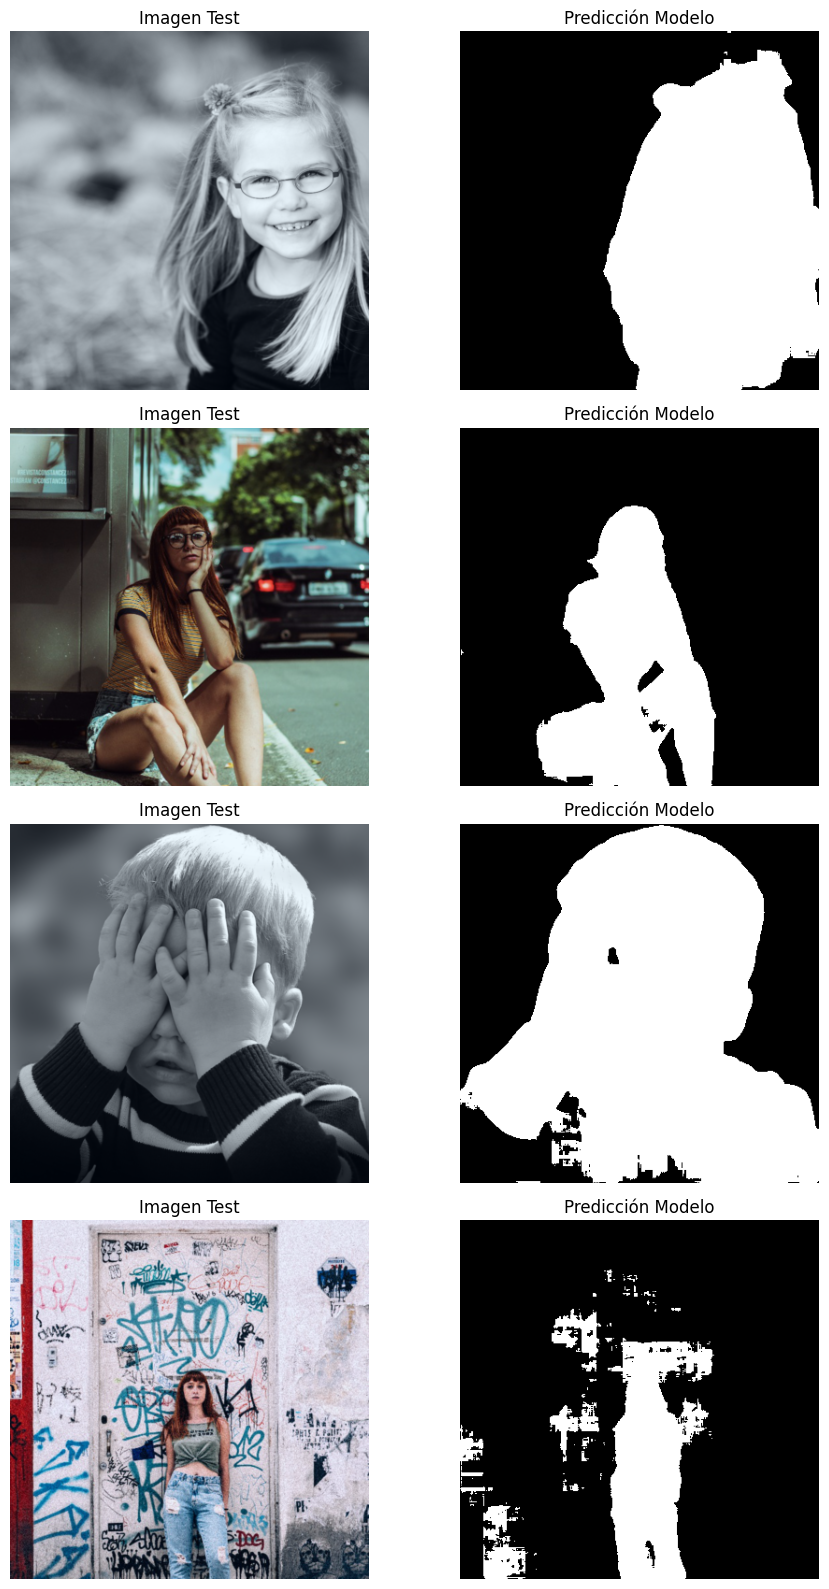

In [175]:
print("Visualizando predicciones en Test...")
visualize_test_predictions(
    model=model_unet, 
    dataloader=test_loader, 
    device=DEVICE, 
    num_samples=4,      # Cuántas imágenes quieres ver
    threshold=0.5
)

# esto tiene que ir mas arriba donde esta train

In [ ]:
def plot_training_history(history):
    """
    Grafica las curvas de entrenamiento y validación.
    
    Args:
        history: Diccionario con 'train_loss', 'train_dice', 'val_loss', 'val_dice'
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Época', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Evolución de la Pérdida', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Dice Score
    axes[1].plot(epochs, history['train_dice'], 'b-', label='Train Dice', linewidth=2)
    axes[1].plot(epochs, history['val_dice'], 'r-', label='Val Dice', linewidth=2)
    axes[1].set_xlabel('Época', fontsize=12)
    axes[1].set_ylabel('Dice Coefficient', fontsize=12)
    axes[1].set_title('Evolución del Dice Score', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0.75, color='g', linestyle='--', label='Target (0.75)', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


def visualize_predictions(model, dataloader, device, num_samples=6, threshold=0.5):
    """
    Visualiza predicciones del modelo comparadas con ground truth.
    
    Args:
        model: Modelo U-Net entrenado
        dataloader: DataLoader con imágenes a visualizar
        device: Dispositivo (cpu/cuda/mps)
        num_samples: Número de muestras a mostrar
        threshold: Umbral para binarizar las predicciones
    """
    model.eval()
    
    # Obtener un batch de datos
    images, masks = next(iter(dataloader))
    images = images.to(device)
    masks = masks.to(device)
    
    # Hacer predicciones
    with torch.no_grad():
        outputs = model(images)
        preds = torch.sigmoid(outputs)
    
    # Seleccionar muestras aleatorias
    indices = np.random.choice(len(images), size=min(num_samples, len(images)), replace=False)
    
    # Visualizar
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        # Imagen original
        img = images[idx].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())  # Normalizar para visualización
        
        # Ground truth
        mask_true = masks[idx, 0].cpu().numpy()
        
        # Predicción
        mask_pred = preds[idx, 0].cpu().numpy()
        mask_pred_binary = (mask_pred > threshold).astype(np.float32)
        
        # Calcular Dice para esta muestra
        dice_score = dice_coefficient_batch(
            preds[idx:idx+1].cpu(),
            masks[idx:idx+1].cpu()
        )
        
        # Graficar
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Imagen Original', fontsize=12)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask_true, cmap='gray')
        axes[i, 1].set_title('Ground Truth', fontsize=12)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(mask_pred, cmap='gray')
        axes[i, 2].set_title(f'Predicción (Raw)', fontsize=12)
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(mask_pred_binary, cmap='gray')
        axes[i, 3].set_title(f'Pred. Binaria\nDice: {dice_score:.3f}', fontsize=12)
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()


def visualize_overlay_predictions(model, dataloader, device, num_samples=3, threshold=0.5):
    """
    Visualiza predicciones superpuestas sobre la imagen original.
    
    Args:
        model: Modelo U-Net entrenado
        dataloader: DataLoader con imágenes a visualizar
        device: Dispositivo (cpu/cuda/mps)
        num_samples: Número de muestras a mostrar
        threshold: Umbral para binarizar las predicciones
    """
    model.eval()
    
    # Obtener un batch de datos
    images, masks = next(iter(dataloader))
    images = images.to(device)
    masks = masks.to(device)
    
    # Hacer predicciones
    with torch.no_grad():
        outputs = model(images)
        preds = torch.sigmoid(outputs)
    
    # Seleccionar muestras aleatorias
    indices = np.random.choice(len(images), size=min(num_samples, len(images)), replace=False)
    
    # Visualizar
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, idx in enumerate(indices):
        # Imagen original
        img = images[idx].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min())
        
        # Ground truth y predicción
        mask_true = masks[idx, 0].cpu().numpy()
        mask_pred = (preds[idx, 0].cpu().numpy() > threshold).astype(np.float32)
        
        # Crear overlays
        overlay_true = img.copy()
        overlay_pred = img.copy()
        
        # Verde para ground truth
        overlay_true[mask_true > 0.5] = overlay_true[mask_true > 0.5] * 0.5 + np.array([0, 1, 0]) * 0.5
        
        # Azul para predicción
        overlay_pred[mask_pred > 0.5] = overlay_pred[mask_pred > 0.5] * 0.5 + np.array([0, 0.5, 1]) * 0.5
        
        # Calcular Dice
        dice_score = dice_coefficient_batch(
            preds[idx:idx+1].cpu(),
            masks[idx:idx+1].cpu()
        )
        
        # Graficar
        axes[i, 0].imshow(img)
        axes[i, 0].set_title('Imagen Original', fontsize=12)
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(overlay_true)
        axes[i, 1].set_title('Ground Truth (Verde)', fontsize=12)
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(overlay_pred)
        axes[i, 2].set_title(f'Predicción (Azul)\nDice: {dice_score:.3f}', fontsize=12)
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()
